In [93]:
import yfinance as yf
import matplotlib.pyplot as plt
import pandas as pd

In [94]:
# Input
def client_input():
    '''
    purpose: function that gathers input when needed
    parameters: None
    return: tickers (str) - used to scrape information. 
            period (str) - used to gather time period of information.
    '''

    # Initialize empty list to hold ticker symbols
    l_tick = []
    
    # While loop to gather ticker symbols from user input
    while True:
        ticker = input("Enter ticker symbol: ").upper()

        # Breaks loop if user entry is empty
        if ticker == "".strip():
            break
        
        # Adds ticker to the end of the 'tickers' list
        l_tick.append(ticker)

    # Gathers period of time for which to gather information
    period = input("Enter period (e.g. 2y, 1y, 6mo, 3mo, 1mo): ")

    return l_tick, period

In [95]:
# Pull data
def pull_data(l_tick, period):
    '''
    purpose: get raw historical price data from one ticker from yfinance
    parameter: ticker_symbol (str) - e.g. "AAPL". period (str) - e.g. "2y".
    return: hist (DataFrame) - daily price data, indexed by date. 
    '''

    # Create an empty dictionary to store the called data for each ticker
    d_tick = {}
    
    # Loop through each ticker in the list of tickers and pull historical data for each
    for ticker in l_tick:

        # Scrape information of current element (ticker) in the list of tickers
        hist = yf.Ticker(ticker).history(period = period)

        # Clean Data - but this is inefficient and can rid of necessary information
        hist = hist.dropna(subset = ['Close'])

        # Add the historical DataFrame to the market_data dictionary with the ticker symbol as the key
        d_tick[ticker] = hist

    return d_tick

In [96]:
# I want each inputed ticker, to scrape the data for its relevant object. 
# Then it will carry its own attributes, this mainly being the dataframe.
# But also will have defining attributes. 
class Security:
    '''
    Attributes: name - type: str - name of corresponding security.
                market_data - type: array - dataframe of corresponding security.
    '''
    def __init__(self, name, raw_market_data):
        self.name = name
        self.raw_market_data = raw_market_data
        self.decision_log = None

    def getMarketData(self):
        return self.raw_market_data

    def __str__(self):
        return self.name

In [98]:
# Indicator Packages

# Simple Moving Averages (SMA)
def s_moving_avg(df, period_1, period_2):
    indicators = pd.DataFrame(index = df.index)

    indicators[f'MA{period_1}'] = df['Close'].rolling(period_1).mean()
    indicators[f'MA{period_2}'] = df['Close'].rolling(period_2).mean()

    return indicators

# Calculate Relative-Strength Index (RSI)
def rsi(df, avg):
    indicators = pd.DataFrame(index = df.index)

    delta = df['Close'].diff()

    gain = delta.where(delta > 0, 0)
    loss = -delta.where(delta < 0, 0)

    avg_gain = gain.rolling(avg).mean()
    avg_loss = loss.rolling(avg).mean()

    rs = avg_gain / avg_loss

    indicators['RSI'] = 100 - (100 / (1+rs))

    return indicators

In [99]:
# Signal Packages

def ma_signal(indicators, period_1, period_2):
    fast = indicators[f'MA{period_1}']
    slow = indicators[f'MA{period_2}']

    golden_cross = (fast > slow) & (fast.shift(1) <= slow.shift(1))
    death_cross = (fast < slow) & (fast.shift(1) >= slow.shift(1))

    return {
        'BUY': bool(golden_cross.iloc[-1]),
        'SELL': bool(death_cross.iloc[-1])
    }

# RSI Signal
def rsi_signal(indicators, oversold, overbought):
    rsi_values = indicators['RSI']

    return {
        'BUY': bool(rsi_values.iloc[-1] <= oversold),
        'SELL': bool(rsi_values.iloc[-1] >= overbought)
    }

In [100]:
# Plugin Registries

INDICATOR_PLUGINS = {
    "moving_average": s_moving_avg,
    "rsi": rsi
}

SIGNAL_PLUGINS = {
    "moving_average_cross": ma_signal,
    "rsi_threshold": rsi_signal
}

In [101]:
# An Order is your instruction to the market
class Order:
    def __init__(
        self,
        security,       # security we wish to purchase
        order_side,     # whether we wish to buy/sell
        order_type,     # whether we choose to place a MARKET or LIMIT order
        quantity_type,  # whether we want our order to placed in SHARE or VALUE
        size,           # from quantity_type then we will ask for the size of SHARES or VALUE
        timestamp       # time of our order placed
    ):
        self.security = security
        self.order_side = order_side
        self.order_type = order_type
        self.quantity_type = quantity_type
        self.size = size
        self.timestamp = timestamp
        self.status = 'PENDING'

In [102]:
# Execution is the market's response to that instruction
class Execution:
    '''
    Attributes: order - type: Order - order that this execution fufills.
                size - type: int/float - quantity of the order that is executed.
                price - type: float - price at which the order is executed.
                timestamp - type: dataframe - time at which the order was executed.
    '''
    def __init__(
        self, 
        order,
        size,
        price,
        timestamp
    ):
        self.order = order
        self.size = size
        self.price = price
        self.timestamp = timestamp

In [103]:
# Transaction records the completed buy or sell in a form that allows us to reconstruct exactly 
# what happened to the portfolio.
class Transaction:
    '''
    Attributes: account - type: Portfolio - account that the transaction occured in.
                security - type: Security - security that was bought or sold. 
                order_side - type: str - whether the transaction was a BUY or SELL. 
                order_type - type: str - type of order that was executed.
                size - type: int/float - number of units bought or sold.
                price - price: float - execution price per unit in the security's denominated currency.
                currency - type: str - currency in which the security was denominated. 
                fx_rate - type: float - exchange rate used to convert the transaction into account's currency.
                total_cost - type: float - total amount applied to the account from the transaction.
                timestamp - type: datetime - time at which the transaction occured. 
    '''
    def __init__(
        self,
        account,
        security,
        order_side,
        order_type,
        size,
        price,
        currency,
        fx_rate,
        total_cost,
        timestamp
    ):
        self.account = account
        self.security = security
        self.order_side = order_side
        self.order_type = order_type
        self.order_side = order_side
        self.size = size
        self.price = price
        self.currency = currency
        self.fx_rate = fx_rate
        self.total_cost = total_cost
        self.timestamp = timestamp

In [104]:
class Portfolio:
    def __init__(self, funds):

        self.funds = funds
        self.initial_funds = funds
        
        # Positions (dict) - will provide the security and of positions it has taken.
        # (e.g. AAPL -> 10 shares)
        self.positions = {}

        # Order placed
        self.orders = []

        # Completed transactions
        self.transactions = []

        # Metrics (df) - will compile given metrics of the portfolio. These metrics should also be plugins. 
        self.metrics = {}

        # Necessary for Sharpe
        self.equity_curve = pd.Series(dtype = float)

    def buy(self, security, size, timestamp):
        order = Order(
            security = security,
            order_side = 'BUY',
            order_type = 'MARKET',
            quantity_type = 'SHARES',
            size = size,
            timestamp = timestamp
        )

        self.orders.append(order)
        return self.process_order(order)

    def sell(self, security, size, timestamp):
        order = Order(
            security = security,
            order_side = 'SELL',
            order_type = 'MARKET',
            quantity_type = 'SHARES',
            size = size,
            timestamp = timestamp            
        )

        self.orders.append(order)
        return self.process_order(order)

    def process_order(self, order):
        if order.order_type == 'MARKET':
            execution = market(order, order.timestamp)

        elif order.order_type == 'LIMIT':
            raise NotImplementedError("LIMIT orders are not implemented yet.")

        else:
            raise ValueError(f"Unsupported order type: {order.order_type}")

        transaction = Transaction(
            account = self,
            security = execution.order.security,
            order_side = execution.order.order_side,
            order_type = execution.order.order_type,
            size = execution.size,
            price = execution.price,

            currency = None,
            fx_rate = None,
            total_cost = execution.size * execution.price,
            timestamp = execution.timestamp
        )

        self.transactions.append(transaction)

        self.update_position(transaction)
        self.update_funds(transaction)
        
        return transaction

    def update_position(self, transaction):
        security = transaction.security

        if security not in self.positions:
            self.positions[security] = 0

        if transaction.order_side == 'BUY':
            self.positions[security] += transaction.size

        elif transaction.order_side == 'SELL':
            self.positions[security] -= transaction.size

        else:
            raise ValueError(f"Unsupported order side: {transaction.order_side}")

    def update_funds(self, transaction):
        value = transaction.size * transaction.price

        if transaction.order_side == 'BUY':
            self.funds -= value

        elif transaction.order_side == 'SELL':
            self.funds += value

        else:
            raise ValueError(f"Unsupported order side: {transaction.order_side}")

In [105]:
# Order Types 
def market(order, timestamp):
    '''
    Executes market order using Close price at timestamp (t)
    '''
    market_data = order.security.getMarketData()

    price = market_data.loc[timestamp, 'Close']

    execution = Execution(
        order = order,          # preserves the link back to the instruction that produced execution
        size = order.size,      # current platform assumes the requested order is fully executed
        price = price,          # simulated execution price from available market data
        timestamp = timestamp   # execution time, rather order's timestamp
        )

    order.status = 'FILLED'

    return execution

# Will eventually be used to add limit orders
def limit(order, market_data, limit_price):
    pass

In [106]:
class Strategy:
    '''
    Defines which packages are used and how their signals contribute to order decision.
    Each signal has a weight. In which positive constributes toward BUY, while negative weight
    biases towards SELL.
    '''
    def __init__(self, indicators, signals, threshold = 1):
        self.indicators = indicators
        self.signals = signals
        self.threshold = threshold

    def apply(self, current_data):
        '''
        Calculate indicators and evaluate each signal using market information supplied by the
        simulation.
        '''
        indicator_data = pd.DataFrame(index = current_data.index)

        for indicator in self.indicators:
            plugin = INDICATOR_PLUGINS[indicator['plugin']]
            result = plugin(current_data, **indicator['parameters'])
            indicator_data = indicator_data.join(result, how = 'outer')

        signal_results = []

        for signal in self.signals:
            plugin = SIGNAL_PLUGINS[signal['plugin']]
            result = plugin(indicator_data, **signal['parameters'])
            signal_results.append({'result': result, 'weight': signal['weight']})

        return signal_results

    def decide(self, signal_results):
        '''
        Combine the signals into one strategy decision.

        BUY signal add its weight.
        SELL signal subtracts its weight.

        The strategy buys when the score reaches the threshold and sells when the score reaches the
        negative threshold.
        '''
        score = 0

        for signal in signal_results:
            result = signal['result']
            weight = signal['weight']

            if result['BUY']:
                score += weight

            if result['SELL']:
                score -= weight

        if score >= self.threshold:
            return 'BUY'

        if score <= -self.threshold:
            return 'SELL'

        return 'HOLD'


In [107]:
def simulate(security, strategy, portfolio):
    '''
    purpose: simulate the strategy through each historical period without allowing future market
             data to influence the current period (t).
    parameters: 
        security - security object being simulated.
        strategy - strategy object containing indicator and signal plugins.
        portfolio - portfolio object placing and receiving orders.
    '''
    market_data = security.getMarketData()
    equity_curve = []
    decisions = [] 

    for timestamp in market_data.index:
        # Only provide the strategy information available at the time.
        current_data = market_data.loc[:timestamp]
        signal_results = strategy.apply(current_data)
        decision = strategy.decide(signal_results)

        position = portfolio.positions.get(security, 0)
        price = current_data['Close'].iloc[-1]

        if decision == 'BUY' and position == 0:
             order_size = portfolio.funds // price  # TODO: placeholder, figure out order allocation
             if order_size > 0:
                portfolio.buy(security, order_size, timestamp) 

        elif decision == 'SELL' and position > 0:
             portfolio.sell(security, position, timestamp)

        position = portfolio.positions.get(security, 0)
        # Portfolio equity
        equity_curve.append(portfolio.funds + position * price)
        decisions.append(decision)

    portfolio.equity_curve = pd.Series(
        equity_curve, 
        index = market_data.index, 
        name = "Portfolio Equity"
    )

    security.decision_log = pd.Series(
        decisions,
        index = market_data.index,
        name = "Decisions" # stored on the security
    )
            
    return portfolio
    

In [108]:
# Portfolio Performance Evaluation
def evaluate_portfolio(portfolio, annual_risk_free_rate = 0.0):
    '''
    Evaluate performance using given metrics.

    Metrics:
        Total Returns
        CAGR
        Annualized Volatility
        Sharpe Ratio
        Maximum Drawdown
        Sortino Ratio
    
    Equity curve contains portfolio's total market value at each point of time. 
    '''
    equity = portfolio.equity_curve.dropna()

    if equity.empty:
        raise ValueError("Portfolio equity curve is empty.")

    initial_value = portfolio.initial_funds
    final_value = equity.iloc[-1]

    # Return
    total_return = (final_value / initial_value) - 1

    elapsed_days = (equity.index[-1] - equity.index[0]).days
    elapsed_years = elapsed_days / 365

    if elapsed_years > 0:
        cagr = (final_value / initial_value) ** (1 / elapsed_years) - 1

    else: 
        cagr = 0

    # Risk
    periodic_returns = equity.pct_change().dropna()

    annualized_volatility = (
        periodic_returns.std() * (252 ** 0.5)
        if not periodic_returns.empty
        else 0
    )

    # Risk-adj performance
    daily_risk_free_rate = ((1 + annual_risk_free_rate) ** (1 / 252) - 1)

    excess_returns = periodic_returns - daily_risk_free_rate

    if excess_returns.std() != 0:
        sharpe_ratio = (excess_returns.mean() / excess_returns.std()) * (252 ** 0.5)
    else:
        sharpe_ratio = 0

    # Sortino only penalizes downside volatility.
    downside_returns = excess_returns[excess_returns < 0]

    if downside_returns.std() != 0:
        sortino_ratio = (excess_returns.mean() / downside_returns.std()) * (252 ** 0.5)
    else:
        sortino_ratio = 0

    # Drawdown
    
    running_peak = equity.cummax()
    drawdown = (equity / running_peak) - 1
    maximum_drawdown = drawdown.min()

    metrics = {
        "Total Return": total_return,
        "CAGR": cagr,
        "Annualized Volatility": annualized_volatility,
        "Sharpe Ratio": sharpe_ratio,
        "Sortino Ratio": sortino_ratio,
        "Maximum Drawdown": maximum_drawdown,
        "Final Portfolio Value": final_value
    }

    return metrics

def print_performance(metrics):
    """Display portfolio performance metrics."""
    print("\n========== PORTFOLIO PERFORMANCE ==========")
    print(f"Final Portfolio Value: ${metrics['Final Portfolio Value']:,.2f}")
    print(f"Total Return:          {metrics['Total Return']:.2%}")
    print(f"CAGR:                  {metrics['CAGR']:.2%}")
    print(
        f"Annualized Volatility: "
        f"{metrics['Annualized Volatility']:.2%}"
    )
    print(f"Sharpe Ratio:          {metrics['Sharpe Ratio']:.2f}")
    print(f"Sortino Ratio:         {metrics['Sortino Ratio']:.2f}")
    print(f"Maximum Drawdown:      {metrics['Maximum Drawdown']:.2%}")

In [109]:
def plot_ticker(security, strategy):
    df = security.getMarketData()

    indicator_data = pd.DataFrame(index = df.index)
    for indicator in strategy.indicators:
        plugin = INDICATOR_PLUGINS[indicator['plugin']]
        result = plugin(df, **indicator['parameters'])
        indicator_data = indicator_data.join(result, how = 'outer')

    plt.figure(figsize = (12,6))
    plt.plot(df.index, df['Close'], label = 'Close', alpha = 0.7)

    for col in indicator_data.columns:
        if col.startswith('MA'):
            plt.plot(indicator_data.index, indicator_data[col], label = col)

    if security.decision_log is not None:
        buys = df.loc[security.decision_log == 'BUY']
        sells = df.loc[security.decision_log == 'SELL']

        plt.scatter(buys.index, buys['Close'], color = 'green', marker = '^', s = 100, label = 'Buy', zorder = 5)
        plt.scatter(sells.index, sells['Close'], color = 'red', marker = 'v', s = 100, label = 'Sell', zorder = 5)

    plt.title(str(security))
    plt.legend()
    plt.show()

In [110]:
def run_engine():
    tickers, period = client_input()

    if not tickers:
        print("No securities entered.")
        return

    market_data = pull_data(tickers, period)

    securities = [
        Security(ticker, market_data[ticker])
        for ticker in tickers
    ]

    # TEST strategy
    strategy = Strategy(
        indicators=[
            {
                'plugin': 'moving_average',
                "parameters": {
                    "period_1": 50,
                    "period_2": 200
                }
            },
            {
                'plugin': 'rsi',
                "parameters": {
                    "avg": 14
                }
            }
        ],
        signals = [
            {
                'plugin': 'moving_average_cross',
                "parameters": {
                    "period_1": 50,
                    "period_2": 200
                },
                "weight": 1
            },
            {
                'plugin': 'rsi_threshold',
                "parameters": {
                    "oversold": 30,
                    "overbought": 70
                },
                "weight": 1
            }
        ],
        threshold = 1
    )

    # one shared portfolio across all tickers, not per ticker
    portfolio = Portfolio(funds=1000)

    for security in securities:
        simulate(security, strategy, portfolio)

    metrics = evaluate_portfolio(portfolio, annual_risk_free_rate=0.0)
    print_performance(metrics)

    for security in securities:
        plot_ticker(security, strategy)


========== PORTFOLIO PERFORMANCE ==========
Final Portfolio Value: $1,860.88
Total Return:          86.09%
CAGR:                  36.47%
Annualized Volatility: 17.90%
Sharpe Ratio:          1.84
Sortino Ratio:         1.81
Maximum Drawdown:      -9.81%


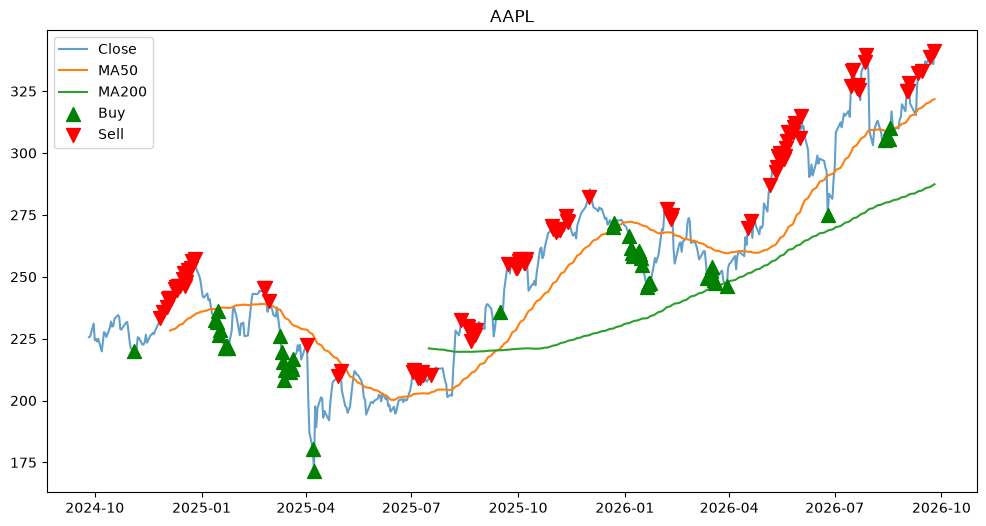

In [111]:
run_engine()

In [ ]:
# TODO: Fix the RSI overshoot, maybe calculate RSI threshold or weight off ticker's beta
# TODO: Still have to fix dead zone
# TODO: Order size allocation
# TODO: Maybe start work on a dashboard/UI